                    name online_order book_table   rate  votes  \
0                  Jalsa          Yes        Yes  4.1/5    775   
1         Spice Elephant          Yes         No  4.1/5    787   
2        San Churro Cafe          Yes         No  3.8/5    918   
3  Addhuri Udupi Bhojana           No         No  3.7/5     88   
4          Grand Village           No         No  3.8/5    166   

   approx_cost(for two people) listed_in(type)  
0                          800          Buffet  
1                          800          Buffet  
2                          800          Buffet  
3                          300          Buffet  
4                          600          Buffet  
Index(['name', 'online_order', 'book_table', 'rate', 'votes',
       'approx_cost(for two people)', 'listed_in(type)'],
      dtype='object')
Average Rating: 3.6331081081081082


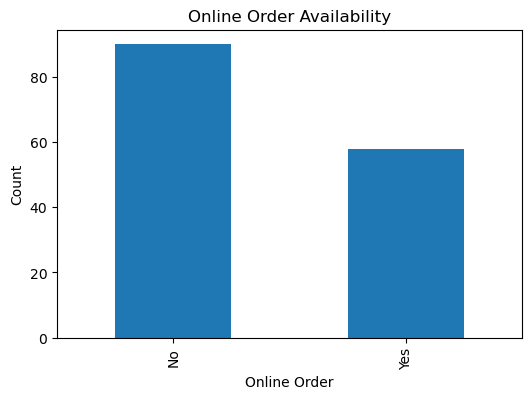

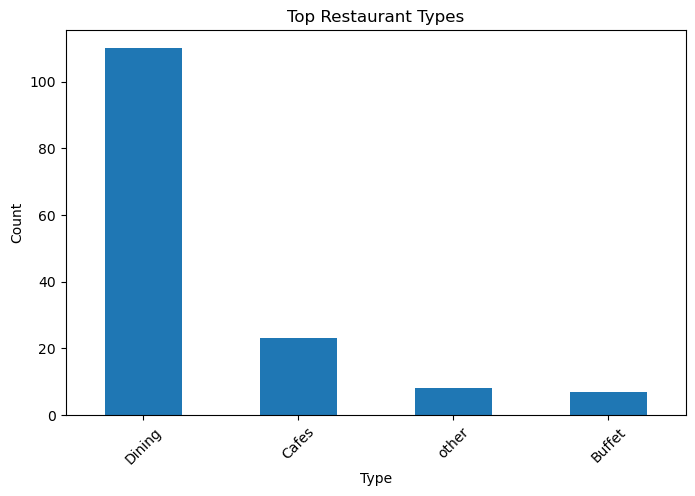

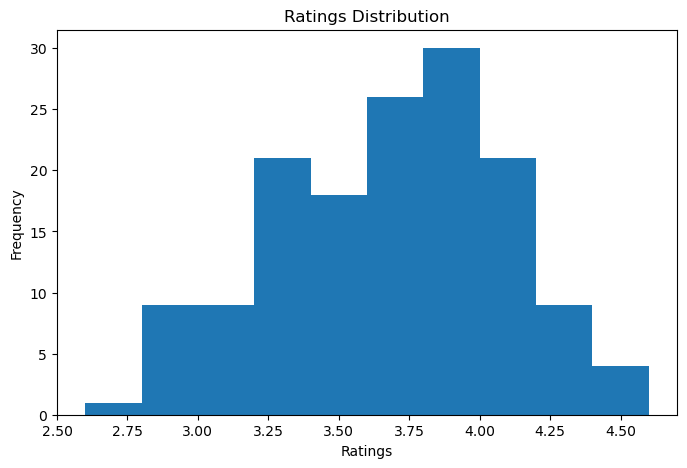

                      name  rate
7                   Onesta   4.6
44                  Onesta   4.6
38       Empire Restaurant   4.4
86           Meghana Foods   4.4
52  Corner House Ice Cream   4.3
                 name  votes
38  Empire Restaurant   4884
86      Meghana Foods   4401
7              Onesta   2556
44             Onesta   2556
65        Kabab Magic   1720


In [6]:
import pandas as pd
import matplotlib.pyplot as plt

zomato = pd.read_csv("Zomato-data-.csv")

print(zomato.head())

print(zomato.columns)

# removing duplicates
zomato.drop_duplicates(inplace=True)

# cleaning rate column
zomato['rate'] = zomato['rate'].astype(str)

zomato['rate'] = zomato['rate'].str.replace('/5', '')

zomato['rate'] = pd.to_numeric(zomato['rate'], errors='coerce')

# removing null values
zomato = zomato.dropna(subset=['rate'])

# average rating
print("Average Rating:", zomato['rate'].mean())

# online order analysis
online_orders = zomato['online_order'].value_counts()

plt.figure(figsize=(6,4))
online_orders.plot(kind='bar')

plt.title("Online Order Availability")
plt.xlabel("Online Order")
plt.ylabel("Count")

plt.show()

# restaurant types
restaurant_types = zomato['listed_in(type)'].value_counts().head(5)

plt.figure(figsize=(8,5))
restaurant_types.plot(kind='bar')

plt.title("Top Restaurant Types")
plt.xlabel("Type")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

# rating distribution
plt.figure(figsize=(8,5))

zomato['rate'].plot(kind='hist', bins=10)

plt.title("Ratings Distribution")
plt.xlabel("Ratings")
plt.ylabel("Frequency")

plt.show()

# top rated restaurants
top_rated = zomato.sort_values(by='rate', ascending=False).head(5)

print(top_rated[['name', 'rate']])

# highest voted restaurants
top_voted = zomato.sort_values(by='votes', ascending=False).head(5)

print(top_voted[['name', 'votes']])